In [2]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

Cupy Available= 1


# [SRDTrans](https://github.com/cabooster/SRDTrans)
By the authors of DeepCAD.

## Decimating 30Hz dataset to 1Hz

In [41]:
meta = DATASETS["synthetic"]
x = Recording(meta.x, max_frames=None)
gt = Recording(meta.gt, max_frames=None)
x.np = x.np[:: meta.hz]
gt.np = gt.np[:: meta.hz]

In [42]:
x.save(meta.x.with_name("x_1hz.tiff"))
gt.save(meta.gt.with_name("gt_1hz.tiff"))

## Very low input SNR 30HZ
Here we use the checkpoint (`Pretrained_0.3Hz_50mWpower_1000frames`) provided by the authors.

In [38]:
frame = 100
max_frames = frame + 1
meta = DATASETS["synthetic"]
x = Recording(meta.x, norm=True, max_frames=max_frames)
y_srd = Recording(meta.dir / "srd.tif", norm=True, max_frames=max_frames)
y_dcad = Recording(meta.dir / "deepcad_150.tiff", norm=True, max_frames=max_frames)
gt = Recording(meta.gt, norm=True, max_frames=max_frames)

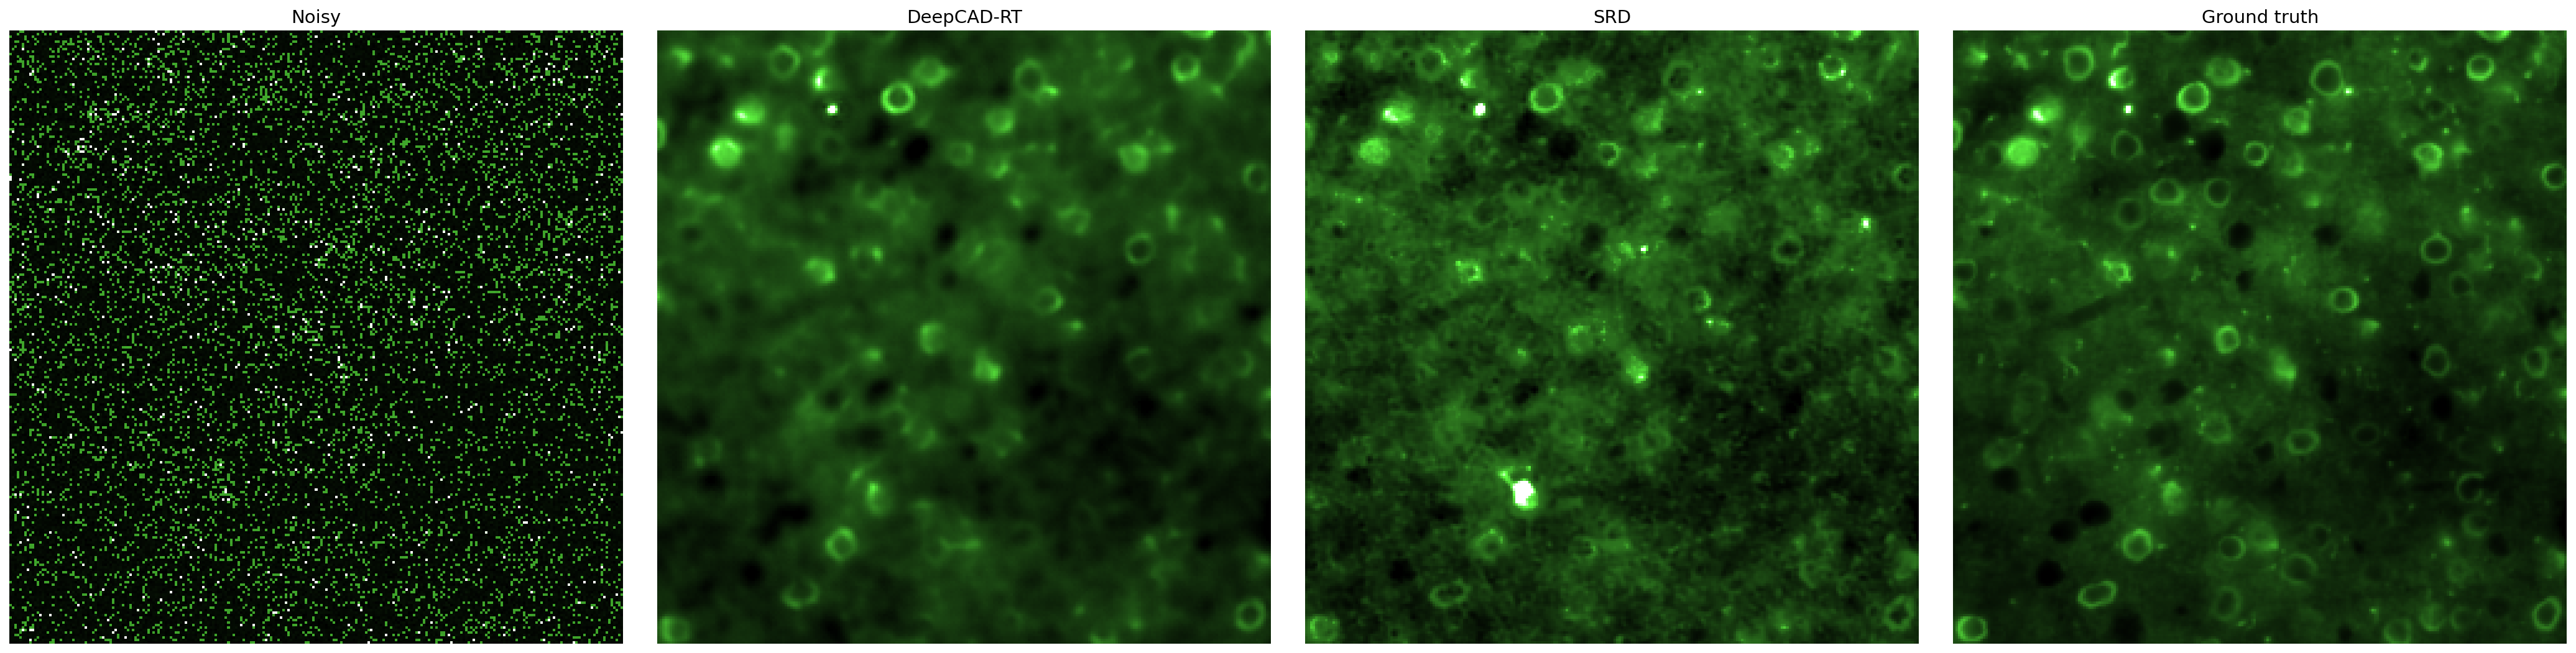

In [39]:
imshow(
    {
        "Noisy": x.np[frame],
        "DeepCAD-RT": y_dcad.np[frame],
        "SRD": y_srd.np[frame],
        "Ground truth": gt.np[frame],
    },
    size=7,
    zoom=2,
)

In [40]:
psnr3d(y_srd.np, gt.np),psnr3d(y_dcad.np, gt.np)

(np.float64(27.260128448521446), np.float64(29.559828779675804))

Results are very good

## Very low input SNR 1HZ

In [12]:
frame = 100
meta = DATASETS["synthetic"]
x = Recording(meta.dir / "x_1hz.tiff", max_frames=None).normalized
y_srd = Recording(meta.dir / "srd_1hz.tif", max_frames=None).normalized
gt = Recording(meta.dir / "gt_1hz.tiff", max_frames=None).normalized

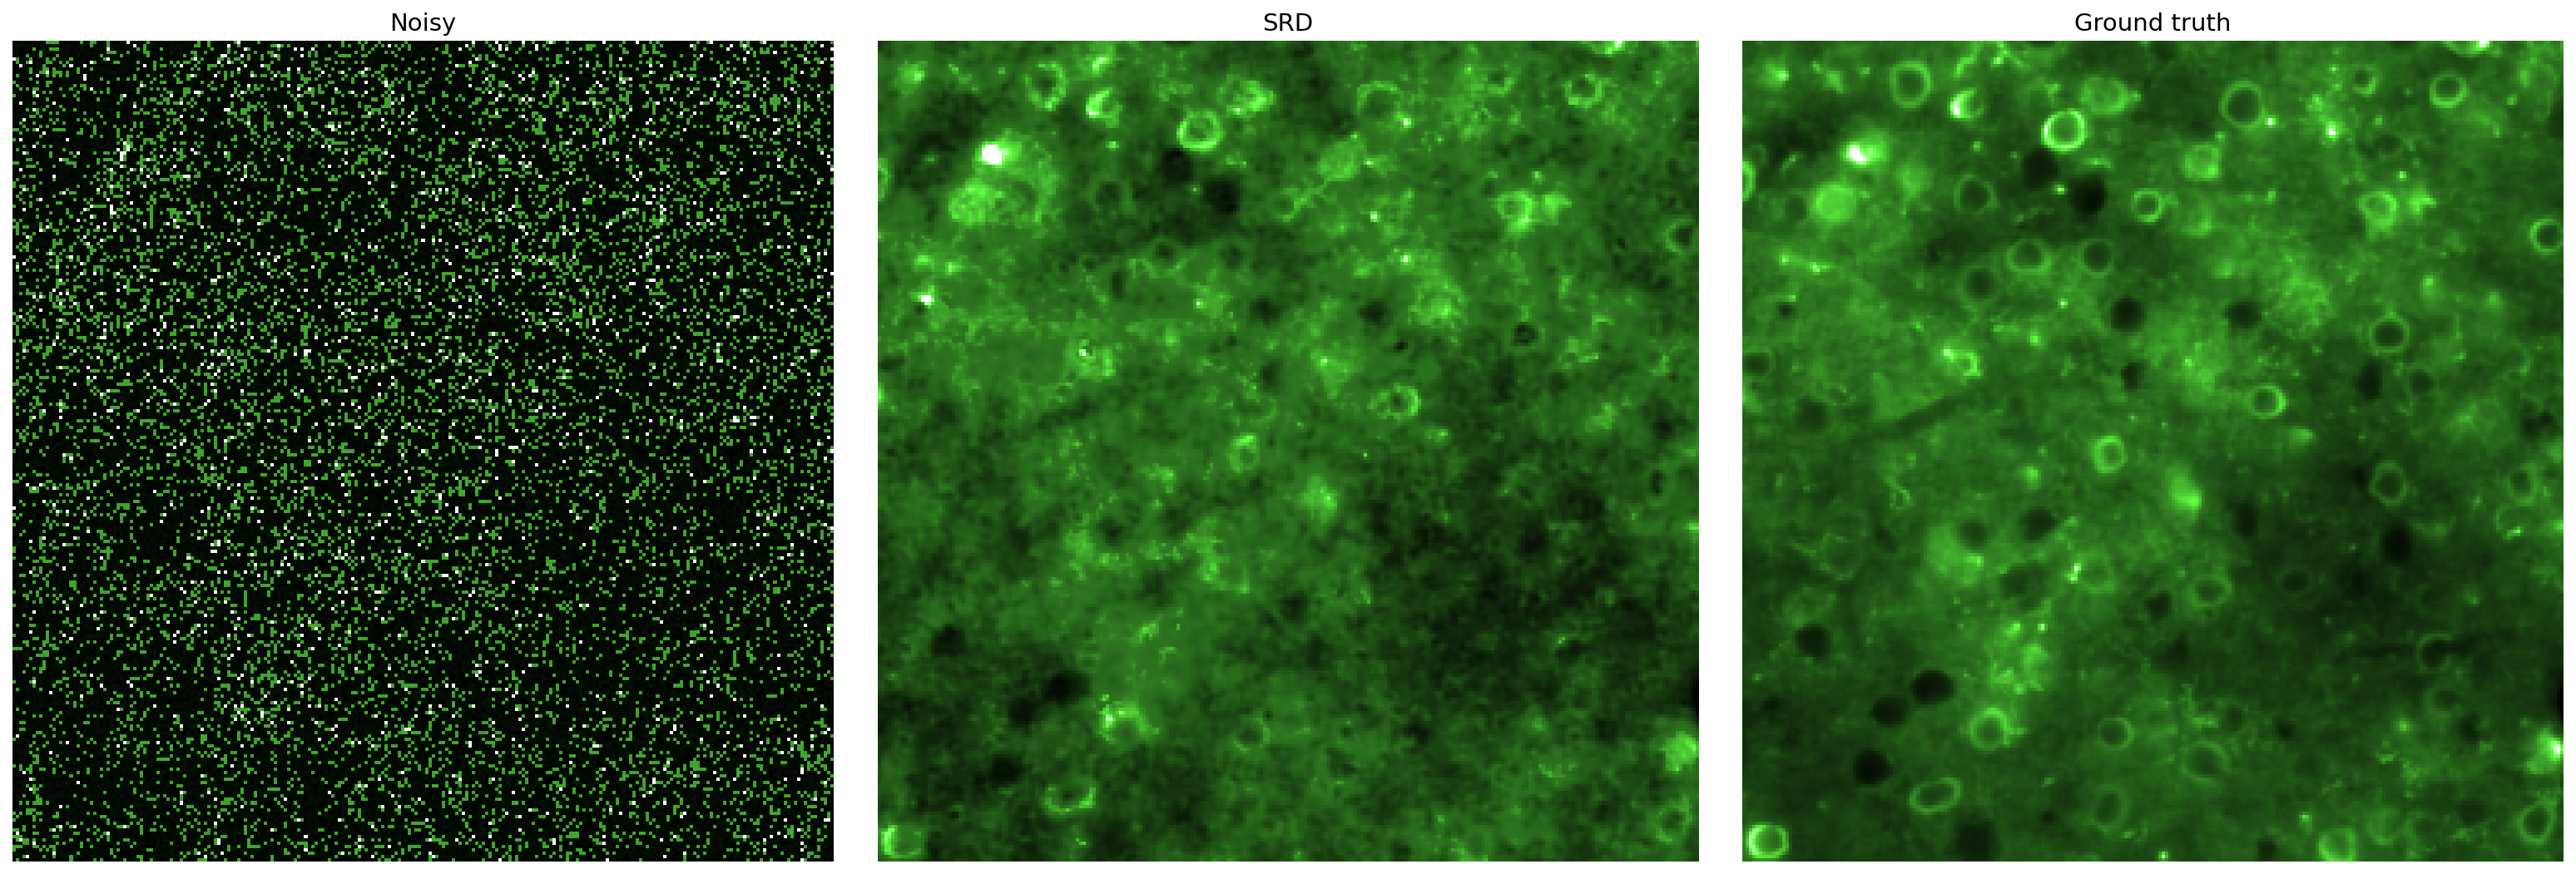

In [13]:
imshow(
    {
        "Noisy": x[frame],
        "SRD": y_srd[frame],
        "Ground truth": gt[frame],
    },
    size=7,
    zoom=2,
)

In [15]:
psnr3d(y_srd, gt)

np.float64(24.518299078613474)